# Job Market — Analytics Notebook

This notebook demonstrates a small analytics layer on top of cleaned job postings.
It computes salary statistics, skill frequency, and description keywords.

In [35]:
import os #
import json #
import pandas as pd # 
import numpy as np
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.util import ngrams
from nltk.corpus import stopwords

import matplotlib.pyplot as plt


In [36]:
# load all cleaned data (from S3 bucket) into an array of dataframes
DATA_DIR = "data"  

dfs = []

for file in os.listdir(DATA_DIR):
    if file.endswith(".json"):
        path = os.path.join(DATA_DIR, file)

        with open(path, "r") as f:
            raw = json.load(f)

        # If file contains a list of jobs
        if isinstance(raw, list):
            df = pd.DataFrame(raw)
        else:
            df = pd.DataFrame([raw])

        dfs.append(df)

full_df = pd.concat(dfs, ignore_index=True)

print("Loaded rows:", len(full_df)) # should be 50 rows per scrape/day.
print("Columns:", list(full_df.columns))
full_df.head()

Loaded rows: 100
Columns: ['title', 'company', 'location', 'description', 'salary', 'skills']


,title,company,location,description,salary,skills
0,Bilingual Data Analyst,TEKsystems,"Toronto, ON","• Our client, a large technology and retail co...","[0, 22]","[Excel, SQL]"
1,Junior Data Analyst,Method One,"Toronto, ON",Overview We are seeking a detail-oriented and ...,"[81, 42]","[Agile, MSSQL, OracleDB, Power BI, Python, R, ..."
2,"Lead Analyst, Data",BenchSci,"Toronto, ON","We're seeking a Lead Business Analyst, Custome...",None,"[AI, Data Modeling, Git, Looker, SQL, Tableau]"
3,"Senior Data Analyst, Corporate Strategy",CIRO/OCRI,"Toronto, ON","Position Title: Senior Data Analyst, Corporate...",None,"[AI, Excel, Java, MATLAB, MSSQL, Power BI, Pyt..."
4,"Senior Associate, Data Analyst",Posting Date:04/ 06/2025,"Toronto, ON","161 Bay Street (93021), Canada, Toronto,Toront...","[800, 304]","[AWS, Git, Matplotlib, Python, SQL, Tableau]"


In [37]:
def extract_salary_min(s):
    if isinstance(s, list) and len(s) == 2:
        return s[0]
    return np.nan

def extract_salary_max(s):
    if isinstance(s, list) and len(s) == 2:
        return s[1]
    return np.nan

full_df["salary_min"] = full_df["salary"].apply(extract_salary_min)
full_df["salary_max"] = full_df["salary"].apply(extract_salary_max)
full_df["salary_avg"] = (full_df["salary_min"] + full_df["salary_max"]) / 2

print("Salary stats:")
print(full_df["salary_avg"].describe())

Salary stats:
count        36.000000
mean      35354.013889
std       43298.893343
min          11.000000
25%         430.250000
50%        1018.000000
75%       80000.000000
max      119600.000000
Name: salary_avg, dtype: float64



Top 20 Skills:
               skill  count
1                SQL     54
6             Python     49
12               Git     48
18             Azure     41
16               AWS     38
2              Agile     36
26        Kubernetes     29
23            Docker     29
10                AI     28
38         Terraform     26
14              Java     26
19               ETL     25
25           Jenkins     21
27     Microservices     17
42               GCP     17
21             Spark     15
36  Machine Learning     14
35             Kafka     14
54              REST     14
24    GitHub Actions     14


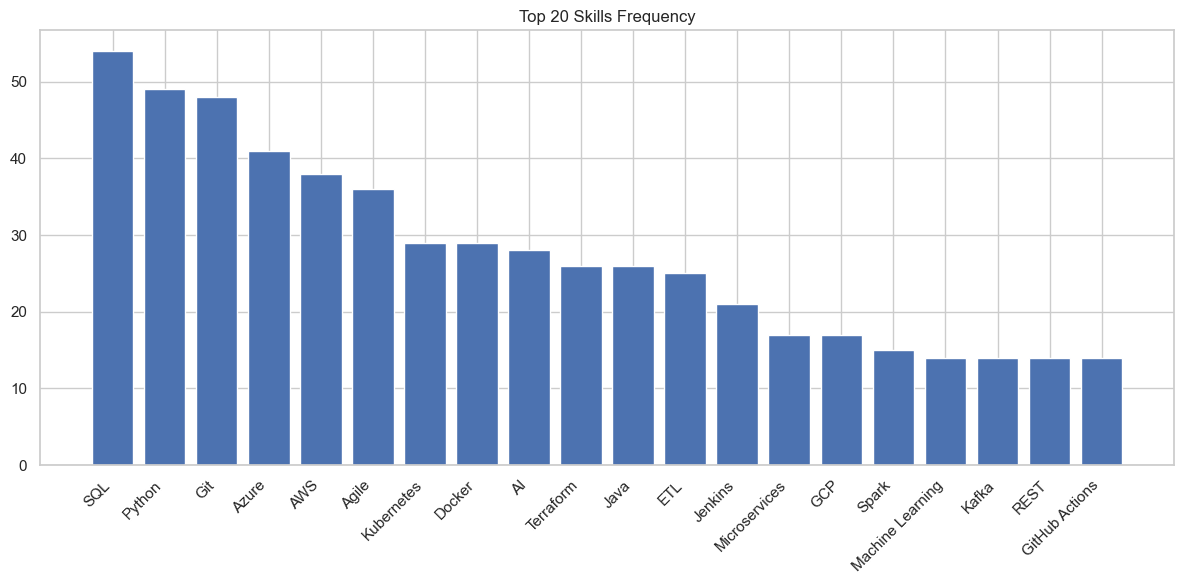

In [38]:
all_skills = []
for skills in full_df["skills"]:
    if isinstance(skills, list):
        all_skills.extend(skills)

skill_counts = Counter(all_skills)
skill_df = pd.DataFrame(skill_counts.items(), columns=["skill", "count"])
skill_df = skill_df.sort_values("count", ascending=False)

print("\nTop 20 Skills:")
print(skill_df.head(20))


# Plot skill frequency (top 20)
top20 = skill_df.head(20)
plt.figure(figsize=(12, 6))
plt.bar(top20["skill"], top20["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 20 Skills Frequency")
plt.tight_layout()
plt.show()



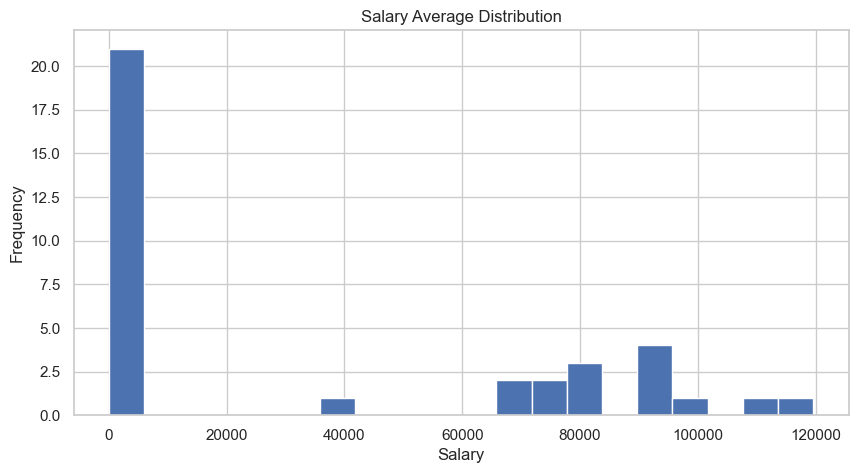


Top 5 Highest Paying Jobs:
                                                title           company  \
61                Senior Specialist, Data Engineering          MCKESSON   
68  Senior Consultant - Data Engineer (Data Conver...          Deloitte   
84                        Principal Ai Cloud Engineer  Bank of Montreal   
76  Backend Developer (Python, C#/.Net), Global De...          Deloitte   
29  Backend Cloud Application Developer, Global De...          Deloitte   

    salary_avg  
61    119600.0  
68    109000.0  
84     96000.0  
76     91500.0  
29     91500.0  


In [39]:
# Salary Distribution Histogram
plt.figure(figsize=(10, 5))
plt.hist(full_df["salary_avg"].dropna(), bins=20)
plt.title("Salary Average Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

# Top 5 highest paying job titles
top_jobs = full_df.sort_values("salary_avg", ascending=False)[["title", "company", "salary_avg"]].head(5)
print("\nTop 5 Highest Paying Jobs:")
print(top_jobs)


In [40]:
descriptions = full_df["description"].fillna("").tolist()

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=50,
    min_df=2
)

tfidf_matrix = vectorizer.fit_transform(descriptions)
keywords = vectorizer.get_feature_names_out()

keyword_scores = tfidf_matrix.sum(axis=0).A1
keyword_df = pd.DataFrame({"keyword": keywords, "score": keyword_scores})
keyword_df = keyword_df.sort_values("score", ascending=False)

print("\nTop TF-IDF Keywords:")
print(keyword_df.head(20))


Top TF-IDF Keywords:
         keyword      score
12          data  28.399907
17    experience  20.442710
10         cloud  13.727711
47          work  12.086501
14   development  11.043214
33        skills  10.114311
32      services   9.966369
43     technical   9.912079
41          team   9.797774
34      software   9.159578
5          azure   8.735931
30          role   8.445451
8       business   8.207141
35     solutions   8.199889
39       support   7.997034
4            aws   7.855594
1             ai   7.430967
13        design   7.421223
3   applications   7.356121
40       systems   7.243372



Title Group Counts:
title_group
Developer        43
Data Analyst     20
Data Engineer    19
Other            18
Name: count, dtype: int64


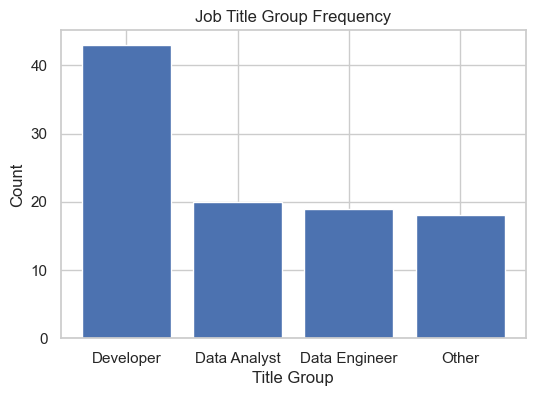

In [41]:
def normalize_title(t):
    t = t.lower()
    if "data engineer" in t:
        return "Data Engineer"
    if "analyst" in t:
        return "Data Analyst"
    if "scientist" in t:
        return "Data Scientist"
    if "developer" in t:
        return "Developer"
    return "Other"

full_df["title_group"] = full_df["title"].apply(normalize_title)

title_counts = full_df["title_group"].value_counts()
print("\nTitle Group Counts:")
print(title_counts)

plt.figure(figsize=(6, 4))
plt.bar(title_counts.index, title_counts.values)
plt.title("Job Title Group Frequency")
plt.xlabel("Title Group")
plt.ylabel("Count")
plt.show()

In [42]:
print("\n--- SUMMARY INSIGHTS ---")

print("Total job postings:", len(full_df))
print("Distinct companies:", full_df['company'].nunique())

print("\nMost common skills:")
print(skill_df.head(10))

print("\nHighest paying roles:")
print(top_jobs.head(5))

print("\nMost relevant TF-IDF keywords:")
print(keyword_df.head(10))

print("\nMost common job title categories:")
print(title_counts)


--- SUMMARY INSIGHTS ---
Total job postings: 100
Distinct companies: 59

Most common skills:
         skill  count
1          SQL     54
6       Python     49
12         Git     48
18       Azure     41
16         AWS     38
2        Agile     36
26  Kubernetes     29
23      Docker     29
10          AI     28
38   Terraform     26

Highest paying roles:
                                                title           company  \
61                Senior Specialist, Data Engineering          MCKESSON   
68  Senior Consultant - Data Engineer (Data Conver...          Deloitte   
84                        Principal Ai Cloud Engineer  Bank of Montreal   
76  Backend Developer (Python, C#/.Net), Global De...          Deloitte   
29  Backend Cloud Application Developer, Global De...          Deloitte   

    salary_avg  
61    119600.0  
68    109000.0  
84     96000.0  
76     91500.0  
29     91500.0  

Most relevant TF-IDF keywords:
        keyword      score
12         data  28.399907
17